# Context Aware Dual Marker Score Annotation (CADuMS)

In [1]:
import scanpy as sc
import celltypist
import pandas as pd
import numpy as np
import importlib
print(f'ScanPy version: {importlib.metadata.version('scanpy')}')
print(f'CellTypist version: {importlib.metadata.version('celltypist')}')
print(f'Pandas version: {importlib.metadata.version('pandas')}')
print(f'Numpy version: {importlib.metadata.version('numpy')}')


ScanPy version: 1.12
CellTypist version: 1.7.1
Pandas version: 2.3.3
Numpy version: 2.3.5


/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


### Load adata and marker lists

In [3]:
region = 'hippocampus' # Options: 'cerebral_cortex', 'hippocampus'
rev_n = 12 # Use 12
input_path = f"/home/ratopin/big_data/nmr/{region}_nmr_adata_optimal{rev_n}.h5ad"


In [4]:
adata = sc.read_h5ad(input_path)

## get clusters from `subcluster.ipynb`

In [ ]:
clusters =pd.read_csv(f"../../results/{region}_recursive_hpo_subclustering_labels.csv", index_col=0)
adata.obs['supercluster'] = clusters['supercluster'].astype('category')
adata.obs['cluster'] = clusters['cluster']
adata.obs['subcluster'] = clusters['subcluster']

In [6]:
print(f'Number of superclusters: {clusters['supercluster'].nunique()}')
print(f'Number of clusters: {clusters['cluster'].nunique()}')   
print(f'Number of subclusters: {clusters['subcluster'].nunique()}')

Number of superclusters: 5
Number of clusters: 34
Number of subclusters: 72


In [7]:
adata

AnnData object with n_obs × n_vars = 13634 × 17592
    obs: 'species', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_tf', 'log1p_total_counts_tf', 'pct_counts_tf', 'n_counts', 'qc_composite', 'qc_label', 'sample_id', 'replicate', 'leiden_1.0', 'leiden_5.0', 'supercluster', 'cluster', 'subcluster'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std', 'is_highly_variable'
    uns: 'hvg',

In [8]:
clusters =pd.read_csv(f"../../optimization/{region}_recursive_hpo_subclustering_labels.csv", index_col=0)
adata.obs['supercluster'] = clusters['supercluster']
adata.obs['cluster'] = clusters['cluster']
adata.obs['subcluster'] = clusters['subcluster']

In [9]:
lineage_tb = pd.read_csv('./ratopin_annotations(Lineage_markers).csv')
lineage_tb

,class,pos_markers,neg_markers
0,Glia,"SOX10, GFAP,S100B,MBP,PLP1,AIF1,CD68,SOX2,NES,...","RBFOX3, MAP2, ENSHGLG00000010365, TUBB2B, NEFL..."
1,Excitatory Neuron,"SLC17A7,SLC17A6, CAMK2A, NEUROD6, TBR1","PVALB,SST,VIP,GAD2"
2,Inhibitory Neuron,"GAD2,GAD1,NKX2-1,LHX8,DLX2,ASCL1,GRIN3A","SLC17A7,PROX1, SATB2"
3,Non-Neural,"PECAM1,FLT1","GFAP, Vim, PDGFRA, RBFOX3, SLC17A7, GAD2, GAD1..."


In [10]:
celltype_tb = pd.read_csv('./ratopin_annotations(Cell-type_markers).csv')
celltype_tb

,parent,class,pos_markers,neg_markers
0,Glia,Astrocyte,"GFAP, SLC1A3, SLC1A2, AQP4, S100B, ALDH1L1, AG...","TOP2A, PDGFRA, SLC17A7, GAD1, STMN2, DCX"
1,Glia,Astrocyte Precursor Cell,"PTPRZ1,PAX6, HES1, SOX9, Vim, TOP2A, C5, FGFR3","PDGFRA, GFAP, RBFOX3, MBP"
2,Glia,Oligodendrocyte,"MBP,PLP1,MAG,MOG,CNP, BCAS1, NOVA1, LHFPL3, ITPR2","PDGFRA, GFAP, AQP4, TOP2A, PTPRZ1"
3,Glia,Oligodendrocyte Precursor Cell,"PDGFRA,PCDH15,SOX6,DSCAM,CSPG4,SOX10, OLIG2, B...","AQP4,GFAP,ALDH1L1,GJA1, MBP, PLP1, MOG, RBFOX3..."
4,Non-Neural,Microglia,"ITGAM, F13A1, MEF2C, TTL, SRGAP2, IBA1, P2RY1...","MRC1, GFAP, ALDH1L1, SLC17A7, GAD1"
5,Glia,Ependymal,"CFAP299, DNAH11, ZBBX, MLF1, FOXJ1, PIFO","SLC17A7,PDGFRB, GFAP, AQP4, RBFOX3, MBP"
6,Neural Stem Cell,Radial Glia,"PAX6, HES1, SOX2, NES, Vim, FABP7","DCX, MBP, PLP1, EOMES"
7,Neural Stem Cell,Intermediate Progenitor Cell,"EOMES, ASCL1, PPP1R17, PENK, HES6","PAX6, Vim, RBFOX3, SLC17A7, GAD1"
8,Neural Stem Cell,Neuroblast,"DCX, NNAT, STMN1, NCAM1, NTNG1, DLX1, DLX2, NE...","SOX2, NES, GFAP, SLC1A3, RBFOX3, SNAP25, SYT1,..."
9,Excitatory Neuron,Immature Neuron,"CCND2, NEUROD1, STMN2,STMN4, GAP43, CDKN1B, DC...","GFAP, SLC1A3, NES, EOMES, PCNA, MCM2-7, TYMS, ..."


In [11]:
adata.var["highly_variable"].sum()

np.int64(6000)

In [12]:
len(adata.var_names[adata.var["highly_variable_rank"] <= 10000])

7792

In [13]:
def parse_markers(adata, marker_table: pd.DataFrame, top_hvg=5000):
    pos_markers = {}
    not_found_genes_overall = []

    if top_hvg is not None:
        var_names = set(adata.var_names[adata.var["highly_variable_rank"] <= top_hvg])  
    else:
        var_names = set(adata.var_names)

    for i,lst in enumerate(marker_table.pos_markers):
        found_genes = []
        not_found_genes = []
        if lst is not np.nan:
            for gene in lst.split(','):
                gene = gene.strip()
                if gene in var_names:
                    found_genes.append(gene)
                else:
                    not_found_genes.append(gene)
            
            pos_markers[marker_table['class'][i]] = found_genes
            not_found_genes_overall.extend(not_found_genes)
    print(f"Positive markers found in adata.var:")
    print(pos_markers)

    neg_markers = {}
    for i,lst in enumerate(marker_table.neg_markers):
        found_genes = []
        not_found_genes = []
        if lst is np.nan:
            neg_markers[marker_table['class'][i]] = []
            continue
        else:
            for gene in lst.split(','):
                gene = gene.strip()
                if gene in var_names:
                    found_genes.append(gene)
                else:
                    not_found_genes.append(gene)
            
            neg_markers[marker_table['class'][i]] = found_genes
            not_found_genes_overall.extend(not_found_genes)
    print(f"Negative markers found in adata.var:")
    print(neg_markers)
    print(f"Not found genes: {len(not_found_genes_overall)}")
    print(not_found_genes_overall)
    return pos_markers, neg_markers, not_found_genes_overall
    

In [14]:
lineage_pos_markers, lineage_neg_markers, _ = parse_markers(adata, lineage_tb, top_hvg=6000)

Positive markers found in adata.var:
{'Glia': ['SOX10', 'GFAP', 'MBP', 'PLP1', 'AIF1', 'NES', 'PDGFRA'], 'Excitatory Neuron': ['SLC17A7', 'SLC17A6', 'CAMK2A', 'NEUROD6', 'TBR1'], 'Inhibitory Neuron': ['GAD2', 'GAD1', 'NKX2-1', 'LHX8', 'DLX2', 'ASCL1', 'GRIN3A'], 'Non-Neural': ['PECAM1', 'FLT1']}
Negative markers found in adata.var:
{'Glia': ['TUBB2B', 'NEFL', 'NEFH', 'DCX'], 'Excitatory Neuron': ['SST', 'VIP', 'GAD2'], 'Inhibitory Neuron': ['SLC17A7', 'PROX1', 'SATB2'], 'Non-Neural': ['GFAP', 'Vim', 'PDGFRA', 'SLC17A7', 'GAD2', 'GAD1', 'SOX10']}
Not found genes: 8
['S100B', 'CD68', 'SOX2', 'RBFOX3', 'MAP2', 'ENSHGLG00000010365', 'PVALB', 'RBFOX3']


In [15]:
adata

AnnData object with n_obs × n_vars = 13634 × 17592
    obs: 'species', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_tf', 'log1p_total_counts_tf', 'pct_counts_tf', 'n_counts', 'qc_composite', 'qc_label', 'sample_id', 'replicate', 'leiden_1.0', 'leiden_5.0', 'supercluster', 'cluster', 'subcluster'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std', 'is_highly_variable'
    uns: 'hvg',

In [16]:
celltype_pos_markers, celltype_neg_markers, _ = parse_markers(adata, celltype_tb, top_hvg=6000)

Positive markers found in adata.var:
{'Astrocyte': ['GFAP', 'SLC1A3', 'SLC1A2', 'AQP4', 'ALDH1L1', 'FGFR3'], 'Astrocyte Precursor Cell': ['PTPRZ1', 'PAX6', 'HES1', 'SOX9', 'Vim', 'TOP2A', 'C5', 'FGFR3'], 'Oligodendrocyte': ['MBP', 'PLP1', 'MOG', 'CNP', 'BCAS1', 'NOVA1', 'LHFPL3', 'ITPR2'], 'Oligodendrocyte Precursor Cell': ['PDGFRA', 'PCDH15', 'SOX6', 'DSCAM', 'SOX10', 'BCAN', 'GPR17', 'PTPRZ1'], 'Microglia': ['ITGAM', 'F13A1', 'MEF2C', 'TTL', 'P2RY12'], 'Ependymal': ['CFAP299', 'DNAH11', 'ZBBX', 'MLF1', 'FOXJ1', 'PIFO'], 'Radial Glia': ['PAX6', 'HES1', 'NES', 'Vim', 'FABP7'], 'Intermediate Progenitor Cell': ['EOMES', 'ASCL1', 'PPP1R17', 'PENK'], 'Neuroblast': ['DCX', 'STMN1', 'NTNG1', 'DLX1', 'DLX2', 'KITLG', 'NEUROD1', 'NEUROD2', 'BHLHE22', 'DPYSL3'], 'Immature Neuron': ['CCND2', 'NEUROD1', 'STMN2', 'STMN4', 'GAP43', 'DCX', 'ELAVL4', 'DPYSL3'], 'Pyramidal Neuron': ['SLC17A7', 'TAFA1', 'MPPED1', 'ST6GALNAC5', 'PDE1A', 'SATB2', 'KCNQ5', 'EMX1', 'BCL11B', 'RORB', 'FEZF2', 'CAMK2A', 'SYT

In [17]:
# Erythrocytes shold not be present in single nucleus RNA-seq as they lack their nucleus
del celltype_pos_markers['Erythrocyte']

In [18]:
adata.var[adata.var_names.str.contains('ELAVL4', case=False)]


,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches,mean,std,is_highly_variable
ELAVL4,False,False,2560,0.290895,0.255336,82.111662,4163.0,8.334231,2518,True,743.0,0.296098,0.620528,1.390233,2,0.298445,0.695147,True


## Marker-Based Scoring (ScType-based)

We calculate a score for every cell against every marker set. We only keep "High Confidence" cells for training.

In [19]:


# 1. PREPARE THE NET SCORING FUNCTION
def apply_dual_marker_scoring(adata, pos_dict, neg_dict):
    """
    Calculates a Net Score: Positive Marker Signal - Negative Marker Signal.
    """
    all_cell_types = list(pos_dict.keys())
    
    for cell_type in all_cell_types:
        # Get markers, ensuring they exist in the dataset
        pos_list = [g for g in pos_dict[cell_type] if g in adata.var_names]
        neg_list = [g for g in neg_dict.get(cell_type, []) if g in adata.var_names]
        
        # Calculate Positive Score
        if pos_list:
            sc.tl.score_genes(adata, gene_list=pos_list, score_name=f"{cell_type}_pos_score")
        else:
            adata.obs[f"{cell_type}_pos_score"] = 0
            
        # Calculate Negative Score (Penalty)
        if neg_list:
            sc.tl.score_genes(adata, gene_list=neg_list, score_name=f"{cell_type}_neg_score")
        else:
            adata.obs[f"{cell_type}_neg_score"] = 0
            
        # Compute Net Score
        # Logic: Net = Positive - Negative. 
        # We also apply a 'Relativity' clip: if negative signal is stronger than positive, score is 0.
        adata.obs[f"{cell_type}_net_score"] = adata.obs[f"{cell_type}_pos_score"] - adata.obs[f"{cell_type}_neg_score"]
        adata.obs.loc[adata.obs[f"{cell_type}_net_score"] < 0, f"{cell_type}_net_score"] = 0

    # 2. ASSIGN INITIAL LABELS
    net_score_cols = [f"{ct}_net_score" for ct in all_cell_types]
    
    # Find the best fitting cell type for each cell
    adata.obs['marker_label'] = adata.obs[net_score_cols].idxmax(axis=1).str.replace("_net_score", "")
    adata.obs['max_net_score'] = adata.obs[net_score_cols].max(axis=1)
    
    # 3. DEFINE HIGH-CONFIDENCE ANCHORS
    # A cell is "High Confidence" if it has a strong net score (e.g., > 0.1)
    # This excludes cells that have high negative marker expression or weak positive signals.
    adata.obs['reject_prediction'] = adata.obs['max_net_score'] < 0.5
    
    return adata

# Execute the scoring
adata = apply_dual_marker_scoring(adata, celltype_pos_markers, celltype_neg_markers)



In [20]:
exclude_fraction = 0.20
anchor_threshold = np.quantile(
        adata.obs["max_net_score"],
        exclude_fraction
    )
adata.obs['is_confident'] = adata.obs['max_net_score'] > anchor_threshold


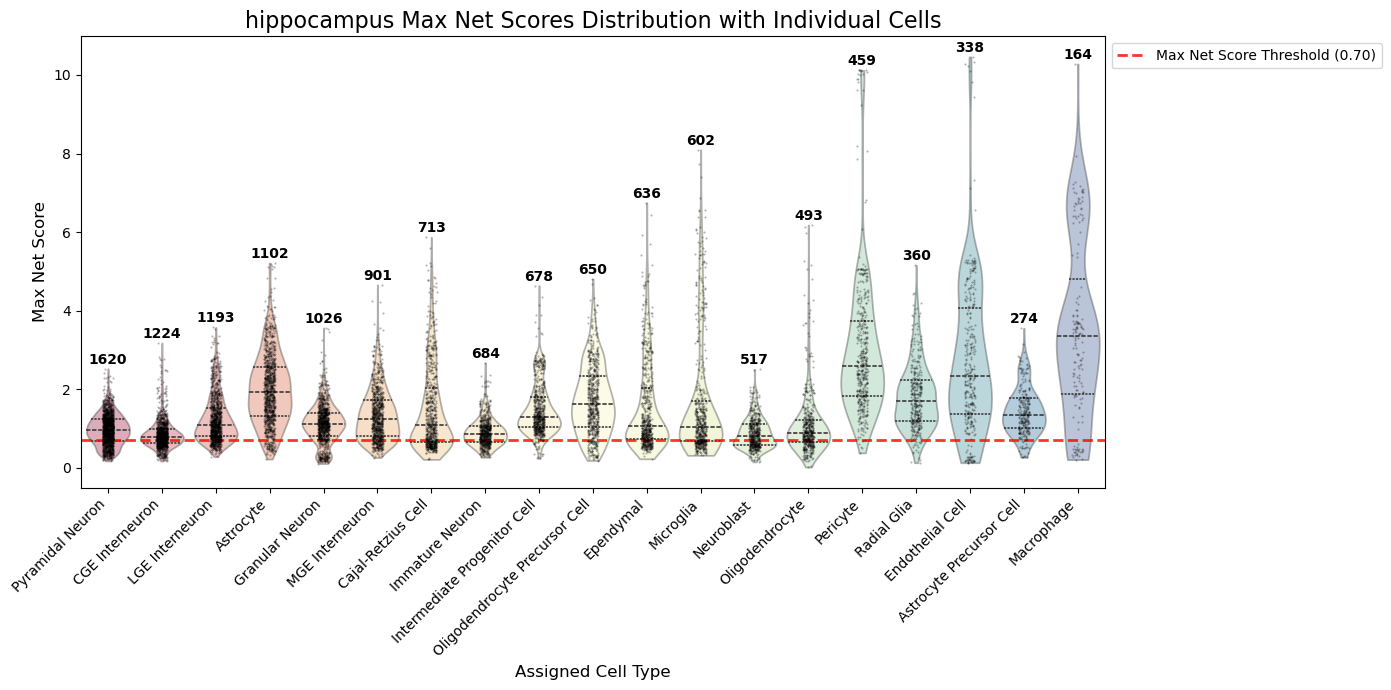

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

group_name = 'marker_label' 
# 1. Ordenar etiquetas por la mediana
order = adata.obs.groupby(group_name)['max_net_score'].count().sort_values(ascending=False).index
n_cells_per_type = adata.obs.groupby(group_name)['max_net_score'].count().sort_values(ascending=False).values

plt.figure(figsize=(14, 7))

# 2. Crear el Violin Plot
sns.violinplot(
    data=adata.obs, 
    x=group_name, 
    y='max_net_score', 
    order=order, 
    palette='Spectral',
    inner='quartile',
    cut=0,
    alpha=0.4  # Hacemos el violín un poco más tenue para resaltar los puntos
)

# 3. Añadir los puntos individuales con Jitter
sns.stripplot(
    data=adata.obs, 
    x=group_name, 
    y='max_net_score', 
    order=order, 
    color='black', 
    size=1.5,      # Puntos pequeños para evitar saturación
    alpha=0.3,     # Transparencia para ver la densidad
    jitter=True    # Desplazamiento aleatorio horizontal
)

# Añadir el número de células por tipo como texto encima de cada violín
for i, (cell_type, count) in enumerate(zip(order, n_cells_per_type)):
    plt.text(i, adata.obs[adata.obs[group_name]== cell_type]['max_net_score'].max() + 0.05, f'{count}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
# 4. Línea de umbral
plt.axhline(anchor_threshold, ls='--', color='red', alpha=0.8, 
            label=f'Max Net Score Threshold ({anchor_threshold:.2f})', linewidth=2)

# 5. Estilo
plt.title(f'{region} Max Net Scores Distribution with Individual Cells', fontsize=16)
plt.ylabel('Max Net Score', fontsize=12)
plt.xlabel('Assigned Cell Type', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left') # Leyenda fuera del gráfico

plt.tight_layout()
plt.savefig(f'figures/{region}_score_distribution_jitter.png', dpi=300)
plt.show()


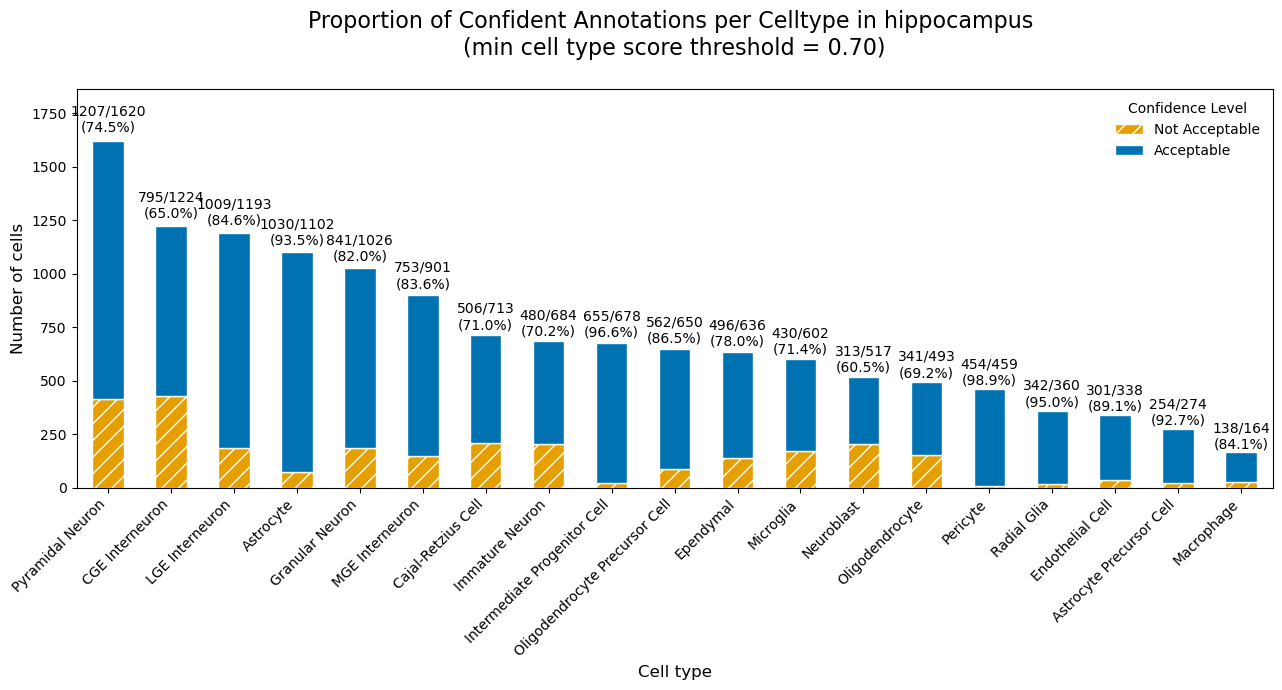

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparar los datos: Contar anclajes y no-anclajes por grupo
# Creamos una tabla cruzada (contingency table)
stack_data = pd.crosstab(adata.obs['marker_label'], adata.obs['is_confident'])

# 2. Renombrar columnas para claridad (asumiendo True/False)
stack_data.columns = ['Not Acceptable', 'Acceptable']

# 3. Calcular el total para poder ordenar descendentemente
stack_data['Total'] = stack_data.sum(axis=1)
stack_data = stack_data.sort_values('Total', ascending=False)

# 4. Eliminar la columna Total para que no se grafique como una barra extra
plot_df = stack_data.drop(columns=['Total'])

# 5. Graficar barras apiladas verticales
# stacked=True coloca 'Confiable' encima de 'No Confiable'
ax = plot_df.plot(kind='bar', stacked=True, figsize=(13, 7), 
                  color=['#E69F00', '#0072B2'], edgecolor='white')
# 6. Añadir etiquetas de texto con el total y el porcentaje de confianza
for i, (name, row) in enumerate(stack_data.iterrows()):
    total = row['Total']
    anchor = row['Acceptable']
    percentage = (anchor / total) * 100
    # Texto sobre la barra: Total de células y % de confianza
    ax.text(i, total + (total * 0.02), f'{int(anchor)}/{int(total)}\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=10, fontweight='regular')
    ax.patches[i].set_hatch('//')


# Configuración estética
plt.title(f'Proportion of Confident Annotations per Celltype in {region} \n(min cell type score threshold = {anchor_threshold:.2f})', fontsize=16, pad=25)
plt.ylabel('Number of cells', fontsize=12)
plt.xlabel('Cell type', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Confidence Level', frameon=False)

# Dar espacio superior para las etiquetas
plt.ylim(0, stack_data['Total'].max() * 1.15)

plt.tight_layout()
plt.savefig(f'figures/{region}_conf_prop_per_celltype.png')

plt.show()


... storing 'cluster' as categorical
... storing 'subcluster' as categorical
... storing 'marker_label' as categorical


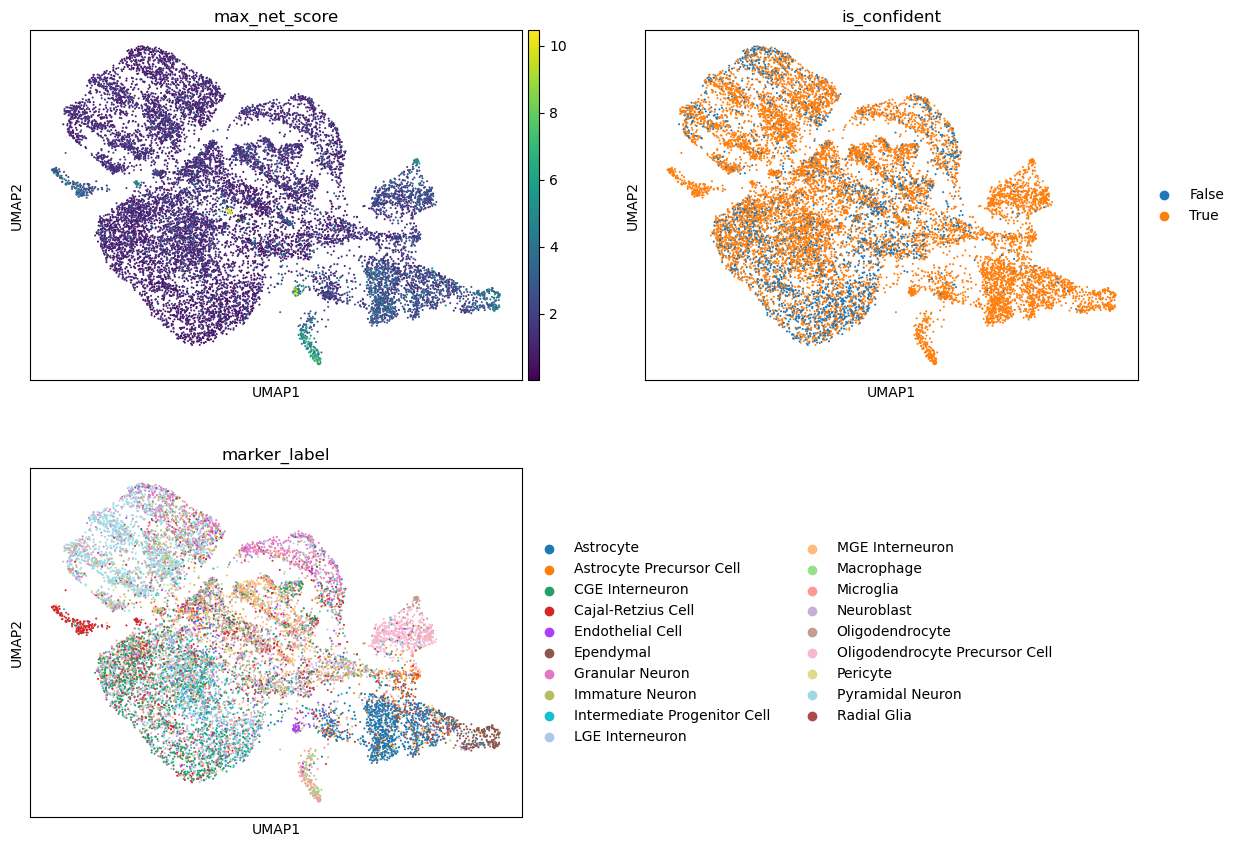

In [23]:
sc.pl.umap(adata, color=['max_net_score','is_confident', 'marker_label'], ncols=2, save=f'_{region}_marker_based_presdiction.png')

In [24]:
pred_col = 'marker_label'
new_col = 'cadums_pred_subcluster'
cluster_col = 'subcluster'
accept_col = 'is_confident'


In [25]:
import pandas as pd


def majority_vote_subcluster(
    adata,
    cluster_col='subcluster',
    pred_col='marker_label',
    accept_col='is_confident',
    new_col='cadums_pred_subcluster',
    confident_thresh=0.70,
    homogeneous_thresh=0.80,
    second_ratio_thresh=0.85
):

    # -----------------------------
    # 1. Confidence per subcluster
    # -----------------------------

    summary = pd.concat([adata.obs[cluster_col].value_counts(),
            adata.obs.loc[adata.obs[accept_col],cluster_col].value_counts()],
        axis=1).fillna(0)

    summary.columns = ['total_cells','confid_cells']

    summary['confid_frac'] = (summary['confid_cells'] / summary['total_cells'])

    low_conf = set(summary.index[summary['confid_frac'] < confident_thresh])

    # -----------------------------
    # 2. Majority vote
    # -----------------------------

    final_labels = {}

    for subcluster in adata.obs[cluster_col].unique():
        cells = (adata.obs[adata.obs[cluster_col] == subcluster])

        counts = (cells[pred_col].astype(str).value_counts())

        if len(counts) == 0:
            continue

        maj1 = counts.index[0]
        n1 = counts.iloc[0]

        frac1 = n1 / counts.sum()

        if len(counts) > 1:
            maj2 = counts.index[1]
            n2 = counts.iloc[1]
            ratio = n2 / n1
        else:
            maj2 = None
            ratio = 0

        high_conf = (
            subcluster
            not in low_conf
        )

        homogeneous = (
            frac1 >= homogeneous_thresh
        )

        # -----------------------------
        # Apply rules
        # -----------------------------        

        if homogeneous:
            if high_conf:
                if ratio < second_ratio_thresh:
                    label = maj1
                else:
                    label = f"{maj1} | {maj2}"
            else:
                if ratio < second_ratio_thresh:
                    label = f"{maj1}*"
                else:
                    label = f"{maj1} | {maj2}*"
        else:
            if high_conf:
                if ratio < second_ratio_thresh:
                    label = "Ambiguous"
                else:
                    label = f"{maj1} | {maj2}*"
            else:
                label = np.nan

        final_labels[subcluster] = label

    # -----------------------------
    # 3. Transfer labels
    # -----------------------------

    adata.obs[new_col] = (adata.obs[cluster_col].map(final_labels))

    # -----------------------------
    # 4. Summary table
    # -----------------------------

    result = (adata.obs.groupby([cluster_col, new_col], observed=True).size().reset_index(name='n_cells'))
    result = result.merge(summary[['confid_frac']],left_on=cluster_col,right_index=True)
    print(f"Assigned {len(final_labels)} subclusters")
    
    return adata, result

In [43]:
adata, vote_summary = majority_vote_subcluster(
    adata, cluster_col='subcluster', pred_col=pred_col, accept_col=accept_col, new_col=new_col,
    confident_thresh=0.70, homogeneous_thresh=0.18, second_ratio_thresh=0.90
)

vote_summary.head()

Assigned 72 subclusters


,subcluster,cadums_pred_subcluster,n_cells,confid_frac
0,0/0/0,CGE Interneuron*,978,0.464213
1,0/0/1,LGE Interneuron*,628,0.590764
2,0/0/2,CGE Interneuron | LGE Interneuron*,54,0.518519
3,0/0/3,CGE Interneuron*,44,0.477273
4,0/1/0,CGE Interneuron,1142,0.722417


... storing 'cadums_pred_subcluster' as categorical


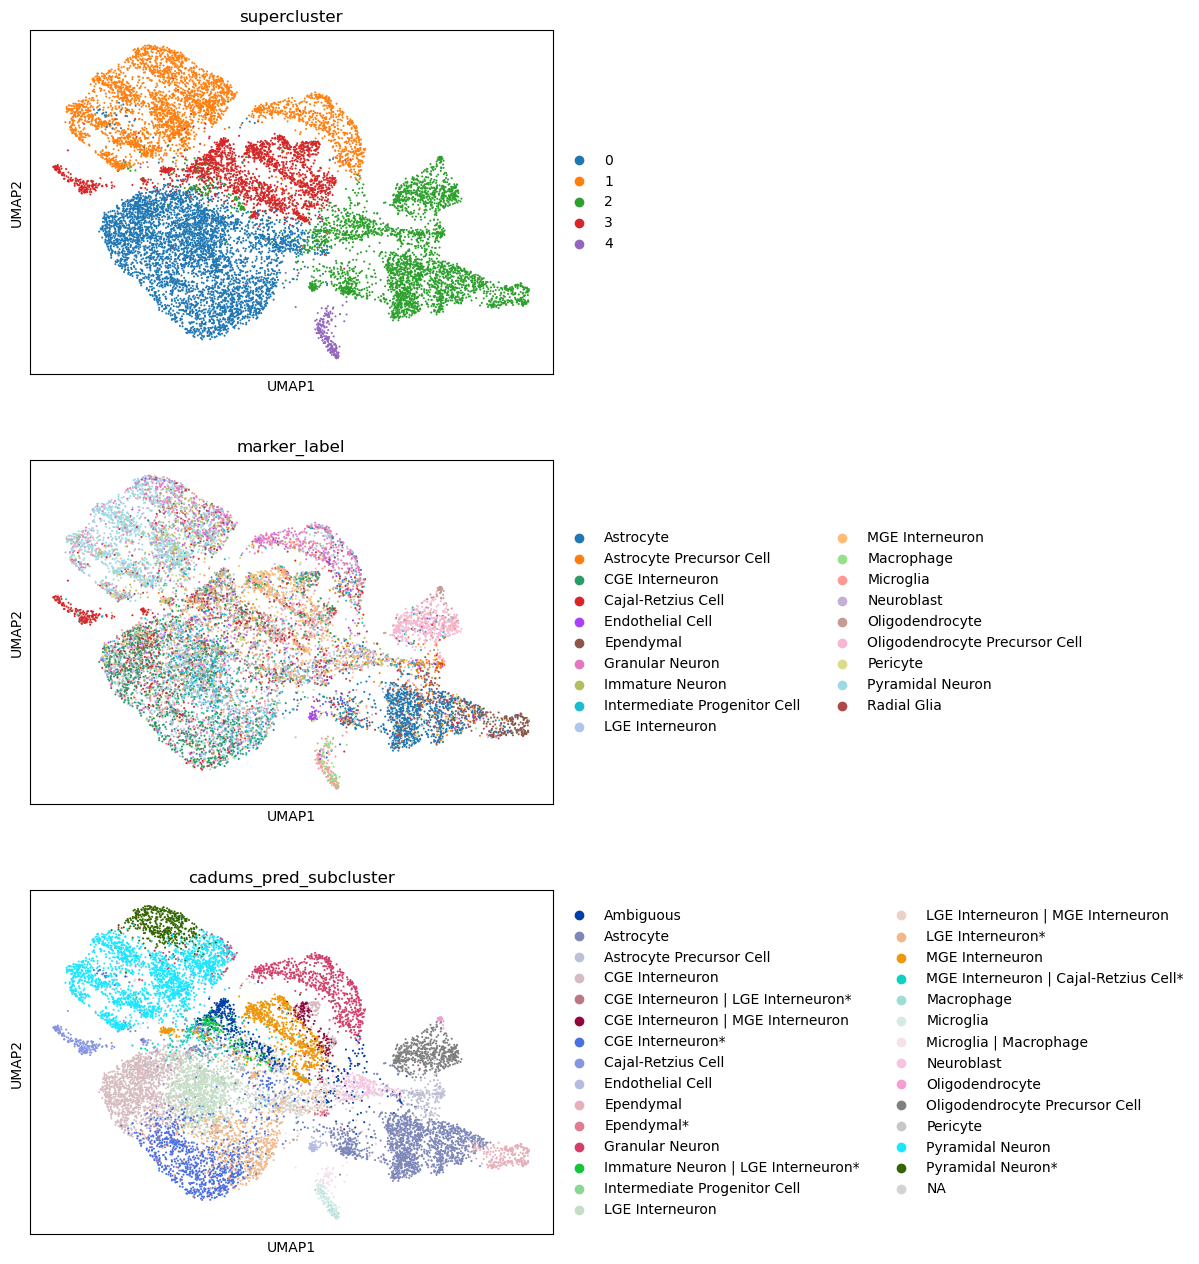

In [44]:
adata.obs['supercluster'] = clusters['supercluster'].astype('category')
sc.pl.umap(adata, color=['supercluster', pred_col, new_col], save=f'_{region}_cadums_pred.png', ncols=1)

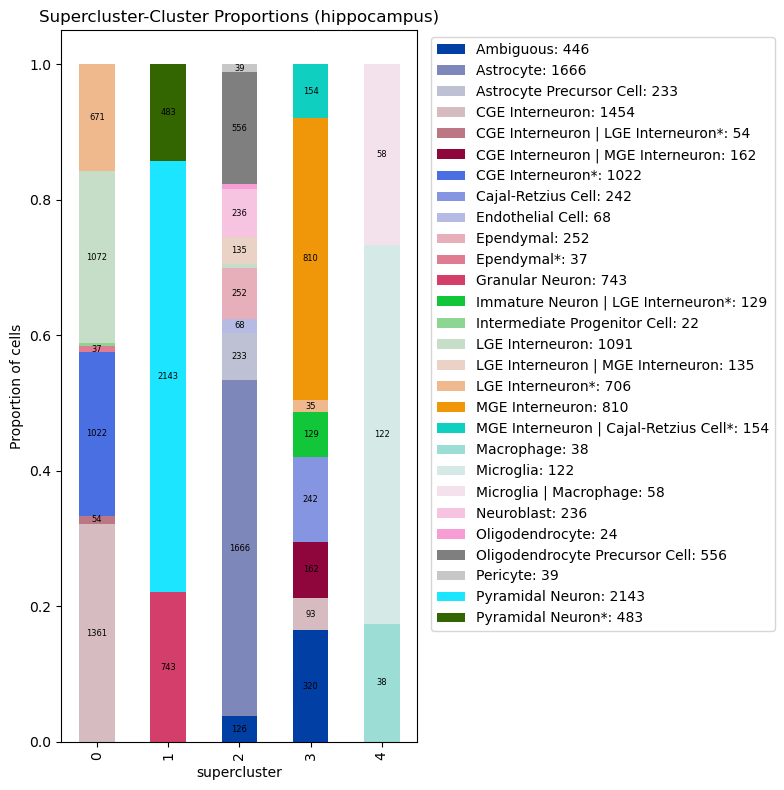

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. raw counts
counts = pd.crosstab(
    adata.obs['supercluster'],
    adata.obs[new_col]
)

# 2. proportions
proportions = counts.div(counts.sum(1), axis=0)

# 3. extract AnnData colors
cluster_order = list(counts.columns)

# scanpy stores colors aligned to adata.obs['cluster'].cat.categories
# but we map safely by category order
color_map = dict(zip(
    adata.obs[new_col].cat.categories,
    adata.uns[f'{new_col}_colors']
))

# ensure alignment with plotted columns
colors = [color_map[c] for c in cluster_order if c in color_map]

# 4. plot with fixed colors
ax = proportions[cluster_order].plot(
    kind='bar',
    stacked=True,
    figsize=(8,8),
    color=colors,
    ylabel='Proportion of cells', 
    title=f"Supercluster-Cluster Proportions ({region})"
)

# 5. annotate absolute counts (cutoff 0.1)
for i, supercluster in enumerate(counts.index):
    bottom = 0

    for cluster in cluster_order:
        value = proportions.loc[supercluster, cluster]
        raw = counts.loc[supercluster, cluster]

        if raw == 0:
            continue

        if value < 0.008:
            bottom += value
            continue

        ax.text(
            i,
            bottom + value / 2,
            str(int(raw)),
            ha='center',
            va='center',
            fontsize=6
        )

        bottom += value

# 6. legend with total counts per cluster
handles, labels = ax.get_legend_handles_labels()

new_labels = [
    f"{label}: {counts[label].sum()}"
    for label in labels
]
ax.legend(
    handles,
    new_labels,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.savefig(f"{region}_supercluster_cluster_proportions.png", bbox_inches='tight')
plt.tight_layout()
plt.show()

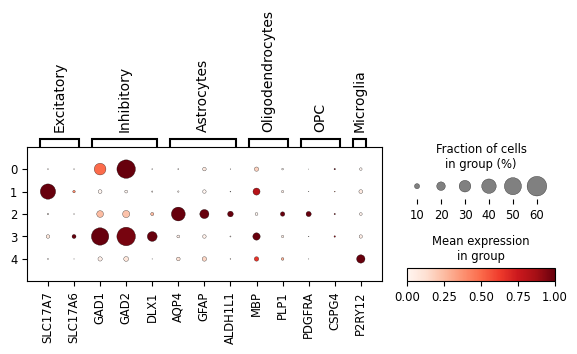

In [46]:
import scanpy as sc

marker_genes = {
    "Excitatory": ["SLC17A7", "SLC17A6"],
    "Inhibitory": ["GAD1", "GAD2", "DLX1"],
    "Astrocytes": ["AQP4", "GFAP", "ALDH1L1"],
    "Oligodendrocytes": ["MBP", "PLP1"],
    "OPC": ["PDGFRA", "CSPG4"],
    "Microglia": ["P2RY12"]
}

# flatten for scanpy
genes = [g for group in marker_genes.values() for g in group]
adata.obs["supercluster"] = adata.obs["supercluster"].astype(str)
adata.obs["supercluster"] = adata.obs["supercluster"].astype("category")
# dotplot
sc.pl.dotplot(
    adata,
    var_names=marker_genes,
    groupby="supercluster",
    standard_scale="var",   # makes markers comparable across genes
    dendrogram=False,
    swap_axes=False,
    cmap="Reds"
)

Missing genes (not in dataset):
{'Mature_Neuron': ['TUBB3'], 'Progenitor': ['MKI67']}


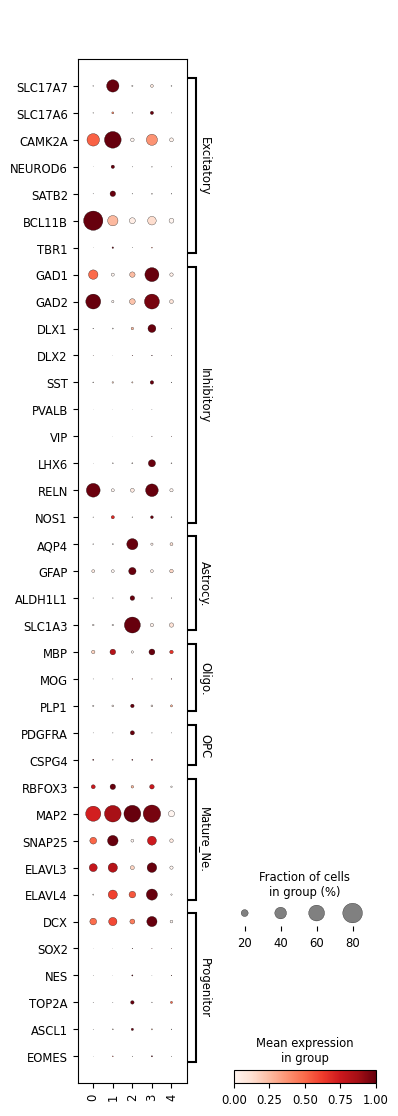

In [47]:
import scanpy as sc

extended_markers = {
    # Excitatory
    "Excitatory": [
        "SLC17A7", "SLC17A6",
        "CAMK2A", "NEUROD6", "SATB2", "BCL11B", "TBR1"
    ],

    # Inhibitory
    "Inhibitory": [
        "GAD1", "GAD2", "DLX1", "DLX2",
        "SST", "PVALB", "VIP", "LHX6", "RELN", "NOS1"
    ],

    # Astrocytes
    "Astrocytes": [
        "AQP4", "GFAP", "ALDH1L1", "SLC1A3"
    ],

    # Oligodendrocytes
    "Oligodendrocytes": [
        "MBP", "MOG", "PLP1"
    ],

    # OPC
    "OPC": [
        "PDGFRA", "CSPG4"
    ],

    # Neuronal maturity / identity
    "Mature_Neuron": [
        "RBFOX3", "MAP2", "TUBB3", "SNAP25",
        "ELAVL3", "ELAVL4"
    ],

    # Immature / progenitor
    "Progenitor": [
        "DCX", "SOX2", "NES", "MKI67", "TOP2A", "ASCL1", "EOMES"
    ]
}

# ----------------------------
# keep only genes present
# ----------------------------
filtered_markers = {
    group: [g for g in genes if g in adata.var_names]
    for group, genes in extended_markers.items()
}

# optional: print missing genes for debugging
missing = {
    group: [g for g in genes if g not in adata.var_names]
    for group, genes in extended_markers.items()
}

print("Missing genes (not in dataset):")
print({k: v for k, v in missing.items() if len(v) > 0})

# ----------------------------
# dotplot
# ----------------------------
sc.pl.dotplot(
    adata,
    var_names=filtered_markers,
    groupby="supercluster",
    standard_scale="var",
    swap_axes=True,
    cmap="Reds"
)

## Validation

In [48]:
sc.tl.dendrogram(adata, groupby=new_col, use_rep="X_pca_harmony")

categories: Ambiguous, Astrocyte, Astrocyte Precursor Cell, etc.
var_group_labels: Astrocyte, Astrocyte Precursor Cell, Oligodendrocyte, etc.


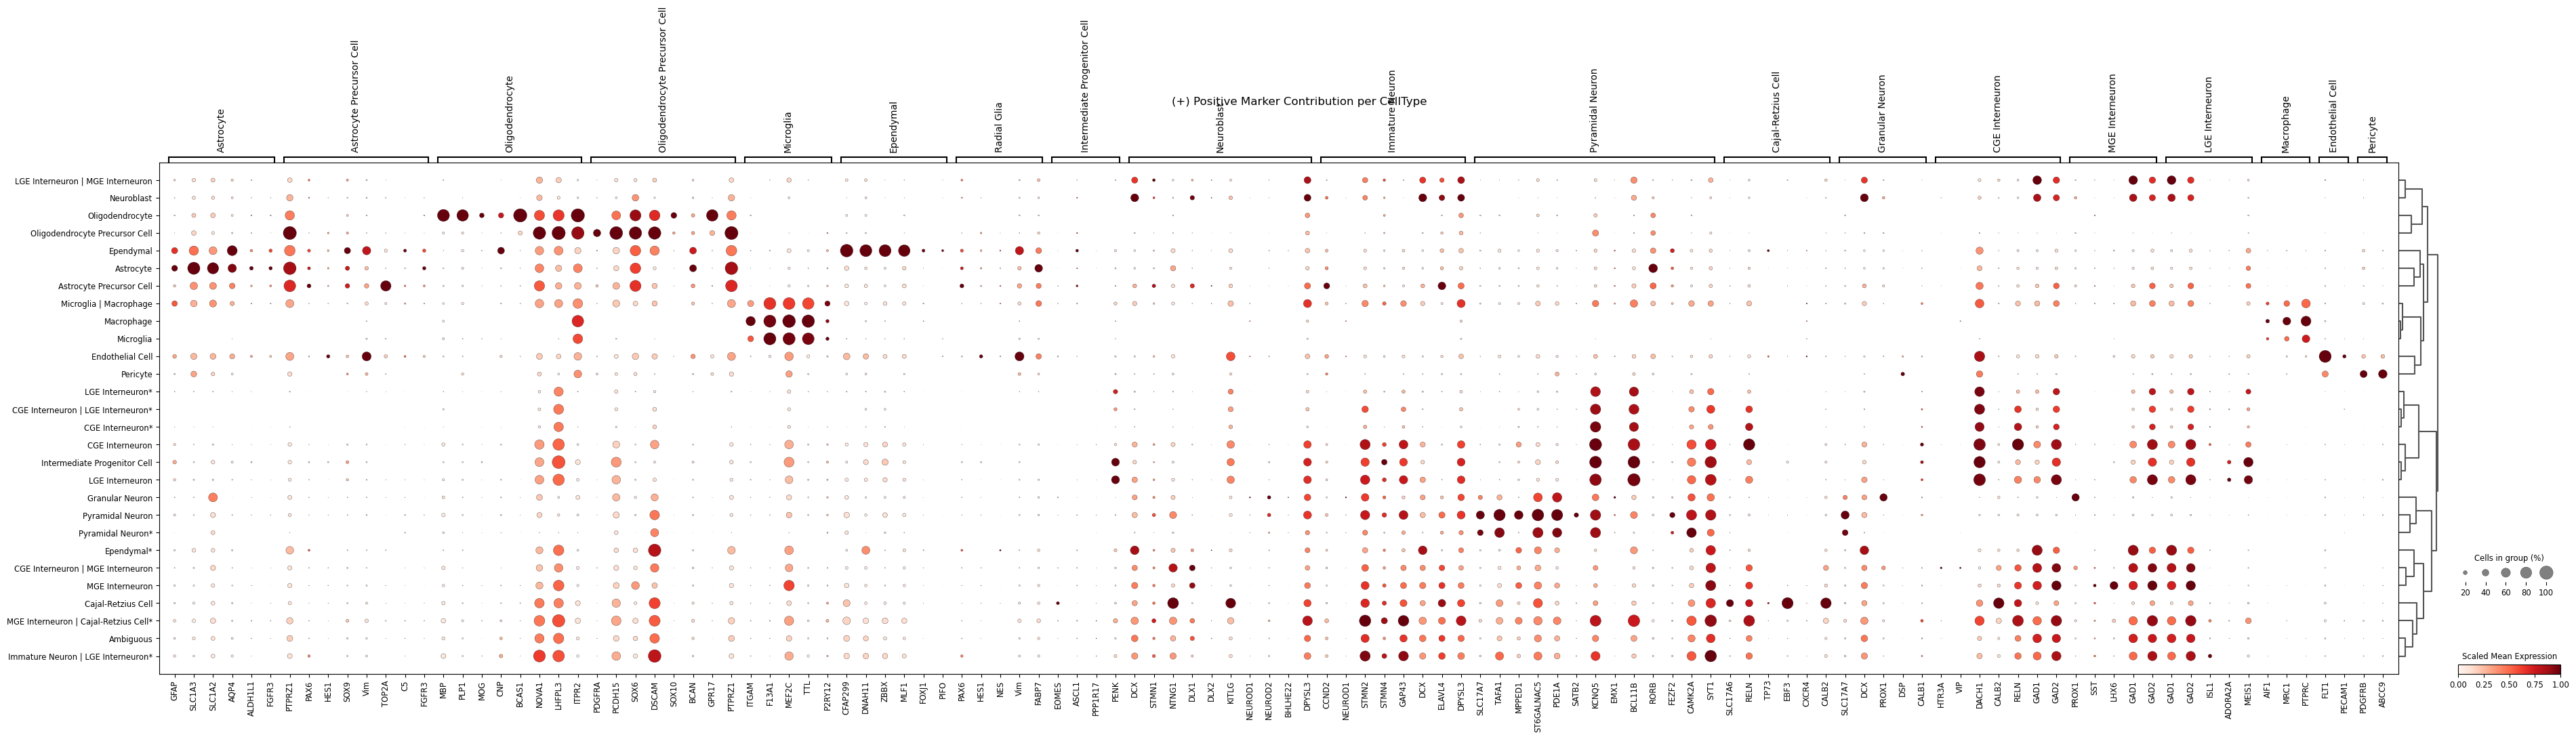

In [49]:
sc.pl.dotplot(
    adata, 
    celltype_pos_markers, 
    groupby=new_col, 
    standard_scale='var',  # Escala de 0 a 1 por gen para comparar mejor
    colorbar_title='Scaled Mean Expression',
    size_title='Cells in group (%)',
    expression_cutoff=0.05, # Oculta puntos con expresión despreciable
    dendrogram=True,        # Agrupa clústeres similares automáticamente
    title="(+) Positive Marker Contribution per CellType",
    swap_axes=False,
    save=f'{region}_positive_marker_contribution_per_celltype_final.png',
)

plt.show()


In [50]:
adata.obs[new_col].to_csv(f'{region}_cadums_predictions.csv')


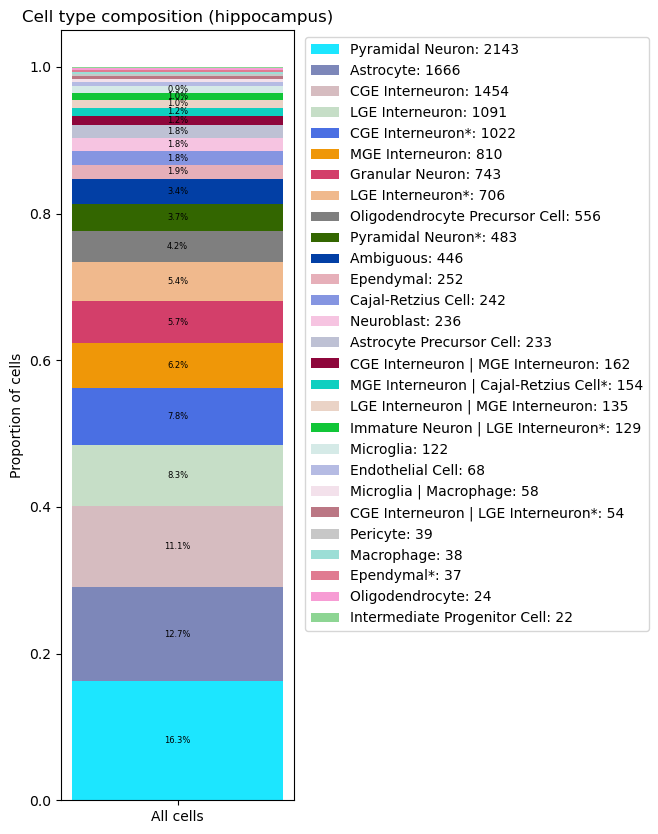

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Count cells and sort descending
counts = (
    adata.obs[new_col]
    .value_counts()
    .sort_values(ascending=False)
)

cluster_order = counts.index.tolist()

# 2. Convert to proportions
proportions = counts / counts.sum()

# 3. Extract colors preserving sorted order
color_map = dict(zip(
    adata.obs[new_col].cat.categories,
    adata.uns[f'{new_col}_colors']
))

# fallback if some labels are not categorical anymore
colors = [
    color_map.get(c, 'lightgray')
    for c in cluster_order
]

# 4. Plot one stacked bar
fig, ax = plt.subplots(figsize=(3, 10))

bottom = 0

for celltype, prop, raw, color in zip(
    cluster_order,
    proportions,
    counts,
    colors
):

    ax.bar(
        x=0,
        height=prop,
        bottom=bottom,
        color=color,
        width=0.8,
        label=celltype
    )

    # annotate percentage
    if prop >= 0.008:
        ax.text(
            0,
            bottom + prop / 2,
            f"{prop*100:.1f}%",
            ha="center",
            va="center",
            fontsize=6
        )

    bottom += prop

# 5. Formatting
ax.set_xticks([0])
ax.set_xticklabels(["All cells"])
ax.set_ylabel("Proportion of cells")
ax.set_title(f"Cell type composition ({region})")

# 6. Legend with counts (same order as stack)
handles, labels = ax.get_legend_handles_labels()

new_labels = [
    f"{label}: {counts[label]}"
    for label in labels
]

ax.legend(
    handles,
    new_labels,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    f"{region}_cadums_global_composition_sorted.png",
    bbox_inches="tight"
)

plt.show()

## get differentially expressed genes

In [35]:
import scanpy as sc

deg_results = {}

for sc_name in adata.obs['supercluster'].unique():

    # subset one supercluster
    sub = adata[
        adata.obs['supercluster'] == sc_name
    ].copy()

    # skip if only one celltype exists
    n_ct = sub.obs[new_col].nunique()

    if n_ct < 2:
        print(f"Skipping {sc_name}: only {n_ct} celltype")
        continue

    print(f"Running DEGs for {sc_name}")

    # DE: each celltype vs other celltypes INSIDE this supercluster
    sc.tl.rank_genes_groups(
        sub,
        groupby=new_col,
        method='wilcoxon',
        reference='rest'
    )

    # Filter
    sc.tl.filter_rank_genes_groups(
        sub,
        groupby=new_col,
        min_fold_change=1.5,
        min_in_group_fraction=0.1
    )

    # store results
    deg_results[sc_name] = sub.uns['rank_genes_groups_filtered']
   

Running DEGs for 1
Running DEGs for 0
Running DEGs for 2
Running DEGs for 4
Running DEGs for 3
